# Classification Models - Part A
This notebook trains and evaluates the classification algorithms for Part A of the Capstone Project.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

# Set display options and random seed
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

## Load Preprocessed Data
We load the scaled and encoded datasets from the `data/classification/` directory.

In [4]:
X_train = pd.read_csv('../data/classification/X_train.csv')
X_test = pd.read_csv('../data/classification/X_test.csv')
y_train = pd.read_csv('../data/classification/y_train.csv').squeeze()
y_test = pd.read_csv('../data/classification/y_test.csv').squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (94337, 92)
X_test shape: (23585, 92)


## 1. Logistic Regression (Baseline Classifier)
Logistic Regression is inherently a binary classification algorithm. To apply it to our multi-class target (`Attack_type_encoded`), we use the One-vs-Rest (OvR) strategy via `OneVsRestClassifier`.

In [8]:
# Initialize and train the Logistic Regression model using One-vs-Rest wrapper
base_log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg = OneVsRestClassifier(base_log_reg)
log_reg.fit(X_train, y_train)

# Generate predictions
y_pred_logreg = log_reg.predict(X_test)
y_pred_proba_logreg = log_reg.predict_proba(X_test)

### Evaluation Metrics

In [9]:
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average='weighted')
    
    print(f"--- {model_name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    
    return {'Model': model_name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC-AUC': roc_auc}

In [10]:
metrics_logreg = evaluate_model(y_test, y_pred_logreg, y_pred_proba_logreg, "Logistic Regression")

--- Logistic Regression ---
Accuracy:  0.9947
Precision: 0.9947
Recall:    0.9947
F1 Score:  0.9947
ROC-AUC:   0.9996


### Confusion Matrix

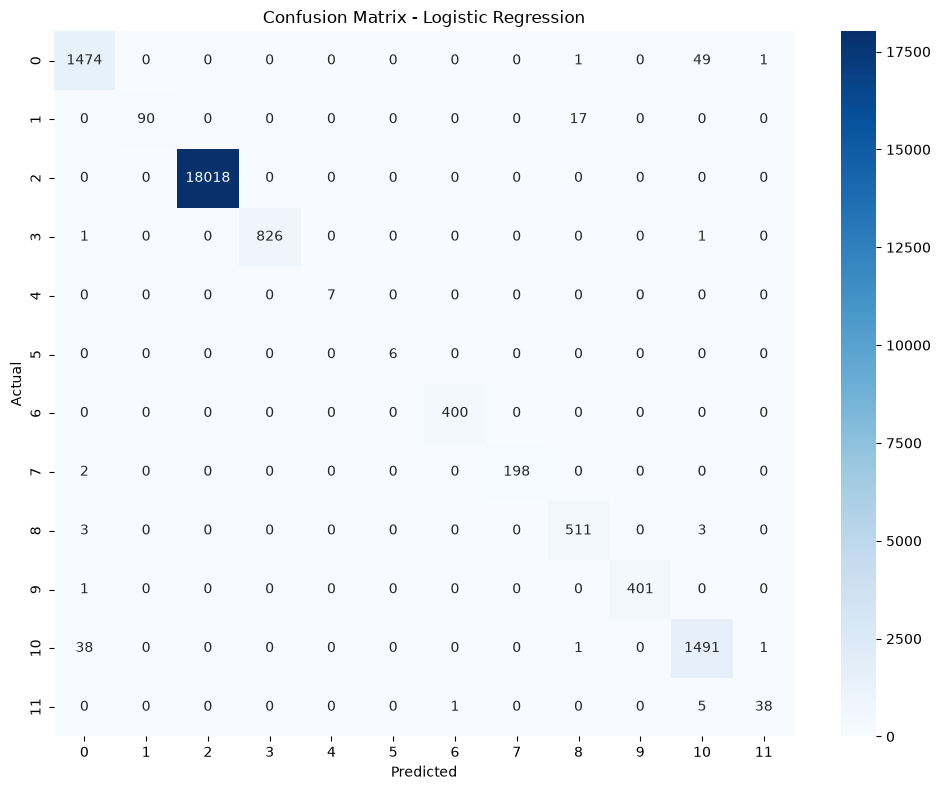

In [14]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_logreg)
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Interpreting Coefficients (Odds Ratios)
Using `OneVsRestClassifier`, we train a separate logistic regression model for each class. We can inspect the coefficients of the first model (Class 0 vs Rest). The coefficients represent the log-odds. By exponentiating them, we get the **odds ratios**. An odds ratio > 1 means the feature increases the probability of the class, while < 1 decreases it.

In [15]:
# Extract coefficients for the first class (Class 0 vs Rest)
coefficients = log_reg.estimators_[0].coef_[0]
odds_ratios = np.exp(coefficients)

# Create a DataFrame for interpretation
feature_names = X_train.columns
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients, 'Odds_Ratio': odds_ratios})

# Show top 5 features that positively influence Class 0 vs Rest
print("Top 5 Features positively influencing Class 0 vs Rest:")
display(coef_df.sort_values(by='Odds_Ratio', ascending=False).head(5))

Top 5 Features positively influencing Class 0 vs Rest:


,Feature,Coefficient,Odds_Ratio
13,fwd_header_size_max,6.327009,559.480677
84,service_dns,2.889505,17.984404
26,fwd_pkts_payload.min,2.725514,15.264255
12,fwd_header_size_min,2.370235,10.699908
69,active.tot,2.249429,9.482318


## 2. K-Nearest Neighbors (KNN)
In this section, we implement the K-Nearest Neighbors classifier. As required by the guidelines, we will tune the hyperparameter `k` (number of neighbors) and discuss the distance metrics.

### Distance Metrics (Euclidean vs. Manhattan)
- **Euclidean Distance** ($L_2$ norm) is the straight-line distance between two points. It is sensitive to large differences in a single feature, which is why scaling our features (which we did in preprocessing) was crucial.
- **Manhattan Distance** ($L_1$ norm) calculates distance as the sum of absolute differences across all dimensions. It can sometimes be more robust in high-dimensional spaces or when dealing with outliers.

We will use `GridSearchCV` to test both distance metrics along with different values of `k` to find the optimal combination.

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for KNN
# Note: Using a smaller subset for k and cv=3 to keep computation time reasonable on this large dataset.
knn_param_grid = {
    'n_neighbors': [3, 5, 7],
    'metric': ['euclidean', 'manhattan']
}

# Initialize KNN model
base_knn = KNeighborsClassifier()

# Setup GridSearchCV
knn_grid = GridSearchCV(base_knn, knn_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit the grid search
print("Tuning K-Nearest Neighbors...")
knn_grid.fit(X_train, y_train)

# Display best parameters
print(f"Best Parameters: {knn_grid.best_params_}")

# The best estimator is automatically retained by GridSearchCV
best_knn = knn_grid.best_estimator_

Tuning K-Nearest Neighbors...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 3}


In [11]:
# Generate predictions with the best model
y_pred_knn = best_knn.predict(X_test)
y_pred_proba_knn = best_knn.predict_proba(X_test)

# Evaluate the model using the function we defined earlier
metrics_knn = evaluate_model(y_test, y_pred_knn, y_pred_proba_knn, "K-Nearest Neighbors")

--- K-Nearest Neighbors ---
Accuracy:  0.9969
Precision: 0.9970
Recall:    0.9969
F1 Score:  0.9969
ROC-AUC:   0.9992


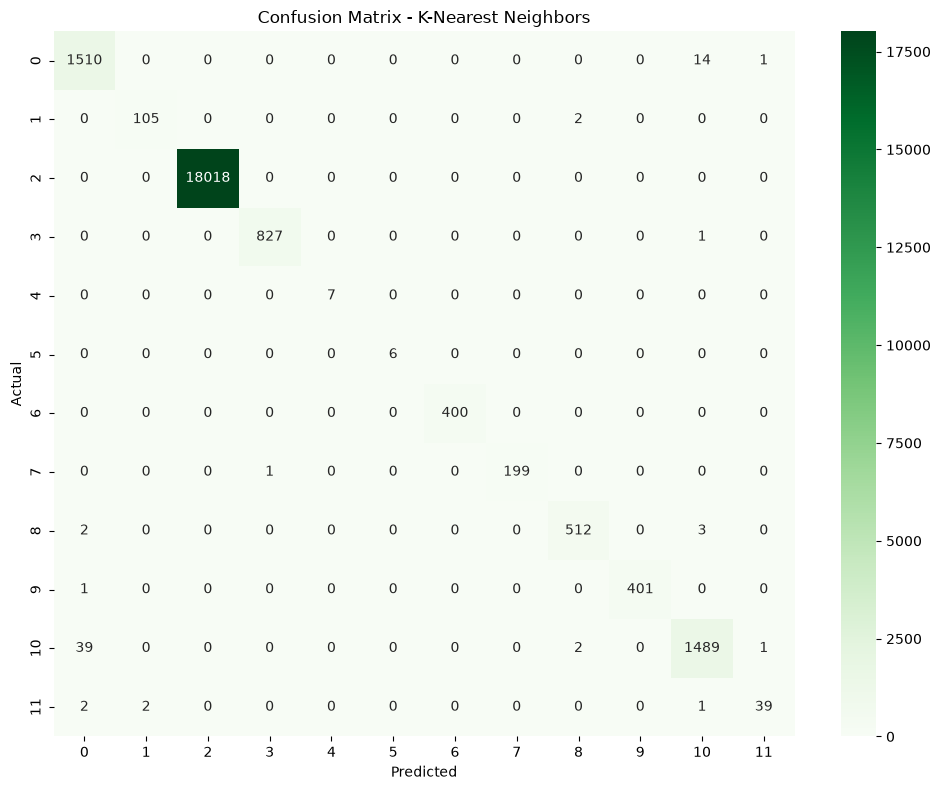

In [12]:
plt.figure(figsize=(10, 8))
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='viridis')
plt.title('Confusion Matrix - K-Nearest Neighbors')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 3. Naive Bayes (Gaussian)

In this section, we train a Gaussian Naive Bayes model. Gaussian Naive Bayes is suitable for continuous features and assumes that the continuous values associated with each class are distributed according to a normal (or Gaussian) distribution.

### Conditional Independence Assumption
Naive Bayes assumes that all features are conditionally independent given the class label. While this assumption is rarely completely true in real-world data (especially in IoT network traffic where packet counts and byte sizes are often highly correlated), the algorithm still typically performs surprisingly well. It serves as a fast, robust baseline classifier that handles noise well.

In [13]:
from sklearn.naive_bayes import GaussianNB

# Initialize the Gaussian Naive Bayes model
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_nb = nb_model.predict(X_test)
# Predict probabilities for ROC-AUC score
y_pred_proba_nb = nb_model.predict_proba(X_test)


In [14]:
# Evaluate Naive Bayes using our custom evaluation function
metrics_nb = evaluate_model(y_test, y_pred_nb, y_pred_proba_nb, 'Gaussian Naive Bayes')


--- Gaussian Naive Bayes ---
Accuracy:  0.9182
Precision: 0.9698
Recall:    0.9182
F1 Score:  0.9281
ROC-AUC:   0.9965


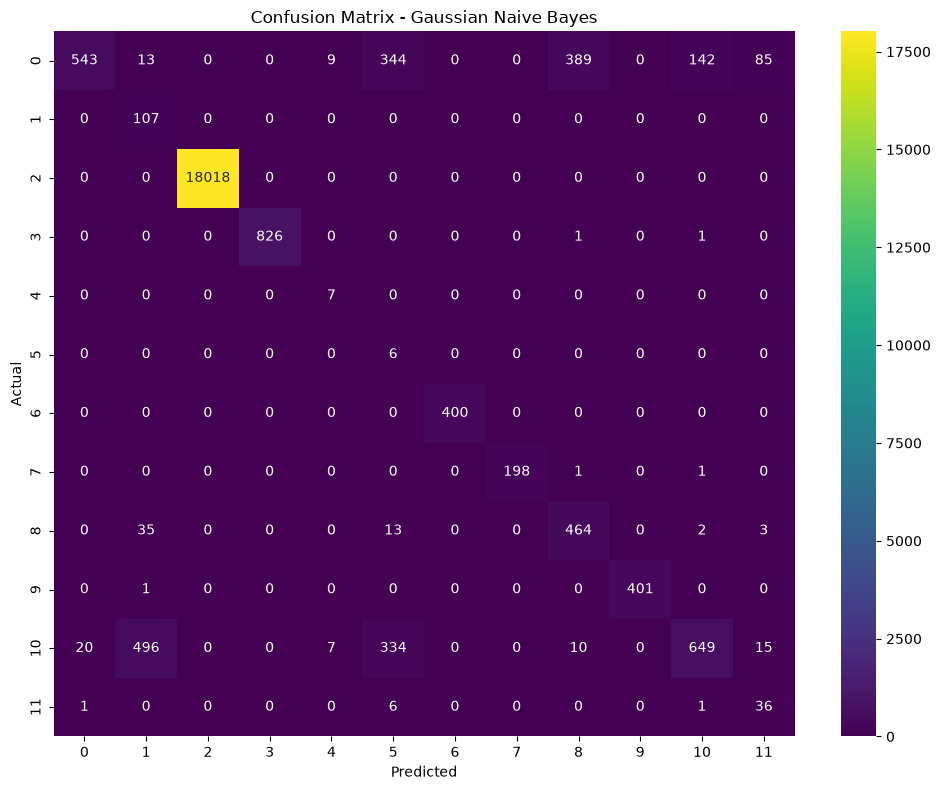

In [15]:
# Plot confusion matrix for Naive Bayes
plt.figure(figsize=(10, 8))
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='viridis')
plt.title('Confusion Matrix - Gaussian Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()
